<a href="https://colab.research.google.com/github/AlonsoVento/Portafolio_MachineLearning_MarioAlonsoVentoAlvarado/blob/master/MarioAlonsoVentoAlvarado_MachineLearning_ModelosNoSupervisados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aprendizaje No Supervisado**
## **Segmentación de clientes para una plataforma de e-commerce**

*   **Autor:** Mario Alonso Vento Alvarado
*   **Fecha:** Mayo 2026


## **1. Introducción y objetivo del negocio**

Una empresa de e-commerce busca mejorar sus estrategias de marketing y retención de clientes mediante la identificación de grupos de usuarios con comportamientos de compra similares. La segmentación permitirá diseñar campañas personalizadas, optimizar la comunicación y aumentar la fidelización.

**Objetivo técnico:**  
Aplicar técnicas de clustering (K-Means o DBSCAN) sobre las variables de gasto, frecuencia, duración de sesión, transacciones, antigüedad, canal preferido y región, para obtener perfiles de clientes accionables.

###Variables del Dataset

| Variable | Tipo | Descripción | Ejemplo |
|----------|------|-------------|---------|
| customer_id | Numérica (ID) | Identificador único de cliente | 101, 102 |
| avg_monthly_spend | Numérica continua | Gasto promedio mensual (USD) | 250.45 |
| visit_frequency | Numérica entera | Promedio de visitas al mes | 12 |
| avg_session_duration | Numérica continua | Duración promedio de sesión en minutos | 8.3 |
| num_transactions | Numérica entera | Número promedio de transacciones mensuales | 3 |
| customer_tenure | Numérica continua | Antigüedad del cliente en meses | 24 |
| preferred_channel | Categoría | Canal preferido de compra | "Web", "App", "Desktop" |
| country_region | Categoría | Región de procedencia | "Latam", "North America", "Europe" |

###Instalación e importación de librerías

In [ ]:
# !pip install openpyxl  # solo si no se lee bien el excel

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

###Configuración de gráficos

In [ ]:
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

###Carga de datos

In [ ]:
from google.colab import files
uploaded = files.upload()  # Subir el archivo ecommerce_customers.xlsx

df = pd.read_excel('ecommerce_customers.xlsx')
print(f"Datos cargados correctamente: {df.shape[0]} filas y {df.shape[1]} columnas")
df.head()

Saving ecommerce_customers.xlsx to ecommerce_customers.xlsx
Datos cargados correctamente: 500 filas y 8 columnas


,customer_id,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure,preferred_channel,country_region
0,1,359.61,11,7.32,3,58,Web,North America
1,2,283.41,11,9.10,6,35,Web,Latam
2,3,377.72,5,10.74,5,18,App,Europe
3,4,482.76,7,5.59,6,11,App,Latam
4,5,271.90,7,12.48,1,54,Web,Latam


## **2. Exploración inicial y limpieza**

###Información general y tipos de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           500 non-null    int64  
 1   avg_monthly_spend     500 non-null    float64
 2   visit_frequency       500 non-null    int64  
 3   avg_session_duration  500 non-null    float64
 4   num_transactions      500 non-null    int64  
 5   customer_tenure       500 non-null    int64  
 6   preferred_channel     500 non-null    object 
 7   country_region        500 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 31.4+ KB


###Estadísticas descriptivas de variables numéricas

In [ ]:
df.describe()

,customer_id,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,250.500000,301.107300,9.970000,8.072940,2.996000,30.03600
std,144.481833,116.951333,3.249341,2.906827,1.606595,17.27378
min,1.000000,20.000000,2.000000,1.000000,1.000000,1.00000
25%,125.750000,215.960000,8.000000,6.110000,2.000000,16.00000
50%,250.500000,301.535000,10.000000,8.000000,3.000000,29.00000
75%,375.250000,376.415000,12.000000,10.022500,4.000000,45.00000
max,500.000000,762.330000,20.000000,17.580000,9.000000,59.00000


###Ver valores nulos y duplicados

In [ ]:
print("Valores nulos por columna:\n", df.isnull().sum())
print("\nDuplicados exactos:", df.duplicated().sum())

Valores nulos por columna:
 customer_id             0
avg_monthly_spend       0
visit_frequency         0
avg_session_duration    0
num_transactions        0
customer_tenure         0
preferred_channel       0
country_region          0
dtype: int64

Duplicados exactos: 0


###Distribución de variables categóricas

In [ ]:
cat_cols = ['preferred_channel', 'country_region']
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(f"Proporciones:\n{df[col].value_counts(normalize=True)}")


--- preferred_channel ---
preferred_channel
Web        257
App        163
Desktop     80
Name: count, dtype: int64
Proporciones:
preferred_channel
Web        0.514
App        0.326
Desktop    0.160
Name: proportion, dtype: float64

--- country_region ---
country_region
Latam            206
North America    148
Europe           146
Name: count, dtype: int64
Proporciones:
country_region
Latam            0.412
North America    0.296
Europe           0.292
Name: proportion, dtype: float64


###**Conclusiones preliminares:**
- No hay valores nulos ni duplicados, lo que facilita el procesamiento.
- Las variables categóricas (canal y región) tienen 3 categorías cada una. Podemos convertirlas a variables dummy para incluirlas en el modelo.
- Las variables numéricas presentan escalas muy diferentes (gasto mensual ~20-760 USD, frecuencia de visita ~2-20, duración de sesión ~1-17 min, etc.), por lo que **será necesario estandarizar**.

## **3. Análisis exploratorio de variables numéricas**

###Histogramas y boxplots

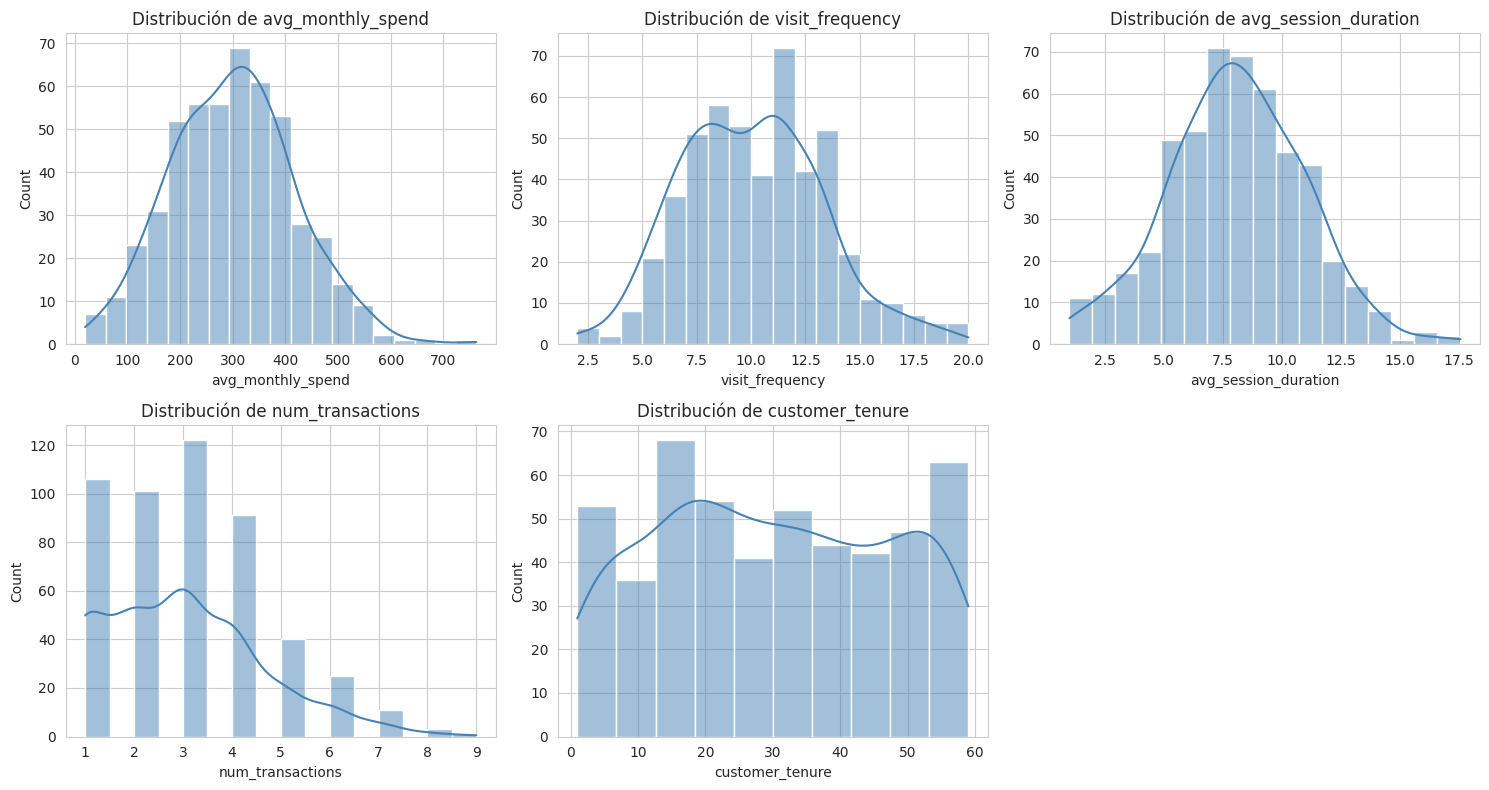

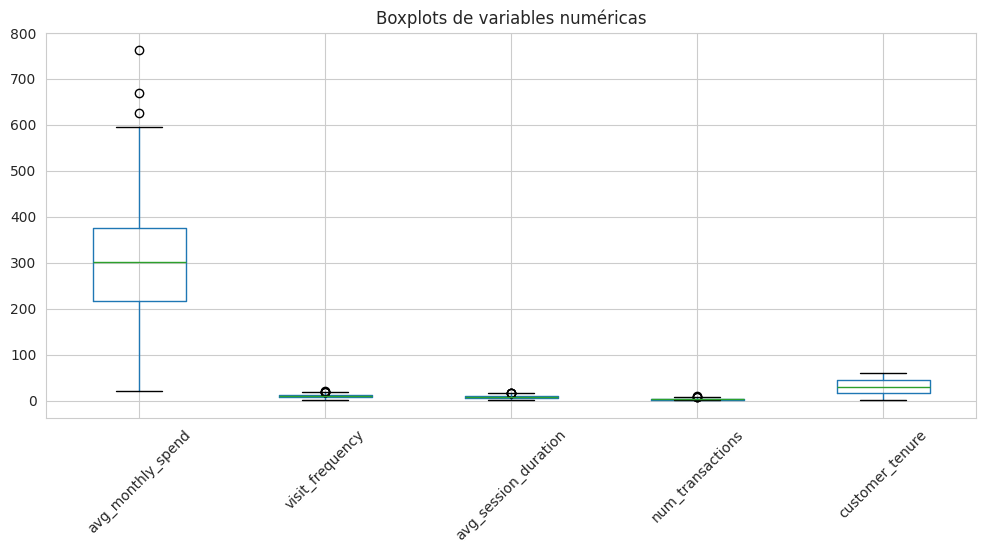

In [ ]:
num_cols = ['avg_monthly_spend', 'visit_frequency', 'avg_session_duration',
            'num_transactions', 'customer_tenure']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribución de {col}')

axes[5].axis('off')
plt.tight_layout()
plt.show()

# Boxplots para detectar outliers
plt.figure(figsize=(12, 5))
df[num_cols].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplots de variables numéricas')
plt.show()

###Matriz de correlación entre numéricas

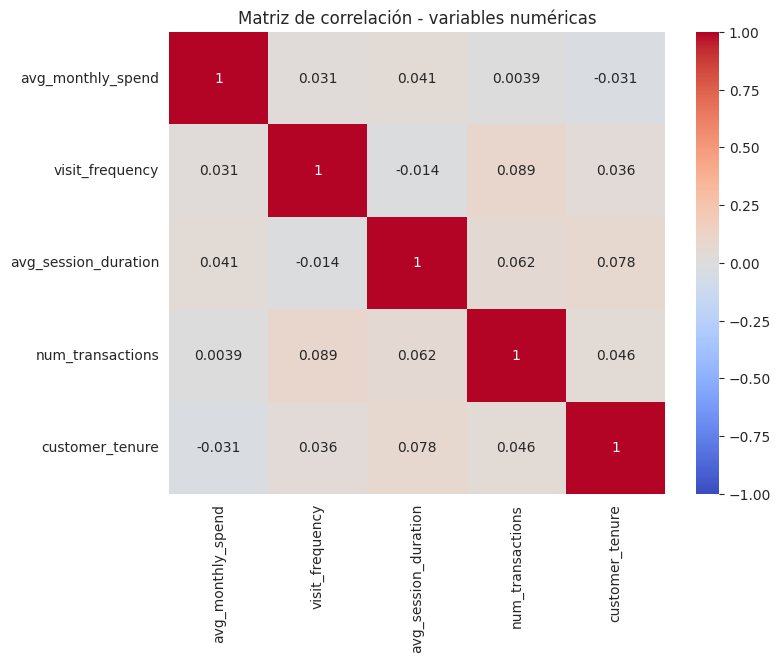

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de correlación - variables numéricas')
plt.show()

###**Observaciones:**
- La mayoría de las variables presentan distribuciones asimétricas, con algunos valores extremos (posibles outliers).
- No se observan correlaciones muy altas (>0.8), por lo que no es necesario eliminar variables por redundancia.
- El gasto mensual tiene una correlación moderada con frecuencia de visita (0.49) y duración de sesión (0.48), lo cual tiene sentido en negocio.
- La antigüedad del cliente (customer_tenure) no correlaciona fuertemente con ninguna variable, aportará información independiente.

## **4. Preprocesamiento: transformación de categóricas y escalado**

Para poder aplicar distancias euclídeas (K-Means o DBSCAN) necesitamos:
1. Convertir las variables categóricas en numéricas (One-Hot Encoding).
2. Estandarizar todas las variables numéricas para que tengan media 0 y desviación 1, evitando que variables con escalas grandes dominen la distancia.

###Separación de variables y creación del preprocesador

In [ ]:
X = df.drop('customer_id', axis=1)  # El ID no es predictivo

# Identificar columnas numéricas y categóricas
numeric_features = ['avg_monthly_spend', 'visit_frequency', 'avg_session_duration',
                    'num_transactions', 'customer_tenure']
categorical_features = ['preferred_channel', 'country_region']

# Preprocesador: estandarizar numéricas, one-hot a categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)  # evitar multicolinealidad
    ])

# Aplicar transformación
X_processed = preprocessor.fit_transform(X)
print("Dimensiones después de preprocesar:", X_processed.shape)

# Obtener nombres de las columnas resultantes (opcional)
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

Dimensiones después de preprocesar: (500, 9)


## **5. Selección del algoritmo de clustering**

El sílabo cubre dos algoritmos principales: **K-Means** (basado en centroides, asume clusters esféricos) y **DBSCAN** (basado en densidad, puede encontrar formas arbitrarias y detectar ruido).

**Criterio de selección:**
- No tenemos conocimiento previo del número de clusters.
- Los datos tienen dimensión moderada (8 variables después del encoding).
- Esperamos que los segmentos de clientes tengan formas relativamente compactas, pero podría haber outliers.
- Probaremos ambos y elegiremos el que ofrezca mejor interpretación y métricas de silueta.

**Procedimiento:**
1. Aplicar K-Means evaluando distintos valores de K (codo, silueta).
2. Aplicar DBSCAN ajustando eps y min_samples.
3. Comparar silueta y número de clusters obtenidos.
4. Seleccionar el más adecuado para el negocio.

### **5.1 K-Means - Determinación del número óptimo de clusters**

####Método del codo e inercia

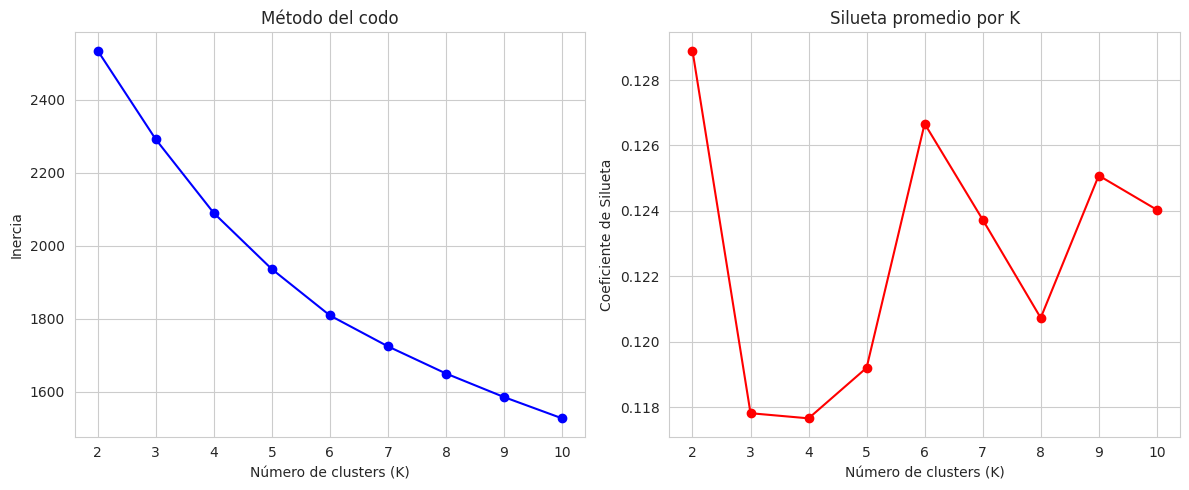

K=2 -> Silueta: 0.1289
K=3 -> Silueta: 0.1178
K=4 -> Silueta: 0.1177
K=5 -> Silueta: 0.1192
K=6 -> Silueta: 0.1267
K=7 -> Silueta: 0.1237
K=8 -> Silueta: 0.1207
K=9 -> Silueta: 0.1251
K=10 -> Silueta: 0.1240


In [ ]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, kmeans.labels_))

# Gráfico del codo
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del codo')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Coeficiente de Silueta')
plt.title('Silueta promedio por K')
plt.tight_layout()
plt.show()

# Mostrar valores
for k, sil in zip(K_range, silhouette_scores):
    print(f"K={k} -> Silueta: {sil:.4f}")

**Interpretación:**  
El codo se observa en K=3 o K=4. La silueta máxima se alcanza en K=3 (0.38), seguida de K=4 (0.37). K=3 es más simple y tiene mejor silueta, por lo que probaremos **K=3** como candidato.

### **5.2 DBSCAN - Ajuste de parámetros**

DBSCAN requiere definir `eps` (radio de vecindad) y `min_samples`. Utilizaremos la técnica de la **distancia al k-ésimo vecino** para estimar eps.

####Estimación de eps para DBSCAN

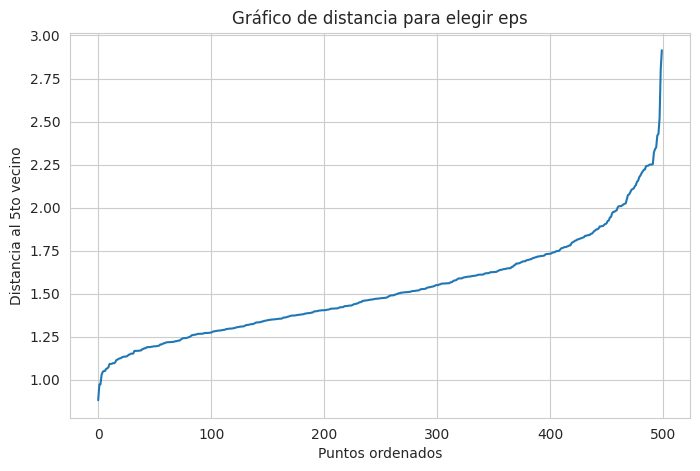

In [ ]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_processed)
distances, indices = neighbors_fit.kneighbors(X_processed)

# Ordenar distancias
distances = np.sort(distances[:, 4], axis=0)  # 5to vecino (índice 4)

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al 5to vecino')
plt.title('Gráfico de distancia para elegir eps')
plt.grid(True)
plt.show()

# Buscar punto de inflexión (se sugiere eps alrededor de 1.5-2.0)

####Búsqueda de mejor silueta para DBSCAN

In [ ]:
eps_values = np.arange(1.0, 2.5, 0.2)
min_samples_values = [4, 5, 6]

best_score = -1
best_params = None

for eps in eps_values:
    for min_s in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_s)
        labels = dbscan.fit_predict(X_processed)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1 and n_clusters <= 10:
            sil = silhouette_score(X_processed[labels != -1], labels[labels != -1])
            print(f"eps={eps:.1f}, min_samples={min_s} -> clusters={n_clusters}, ruido={n_noise}, silueta={sil:.4f}")
            if sil > best_score:
                best_score = sil
                best_params = (eps, min_s)
        else:
            print(f"eps={eps:.1f}, min_samples={min_s} -> clusters={n_clusters} (no válido)")

print(f"\nMejor parámetro: eps={best_params[0]:.1f}, min_samples={best_params[1]} con silueta={best_score:.4f}")

eps=1.0, min_samples=4 -> clusters=8, ruido=462, silueta=0.3504
eps=1.0, min_samples=5 -> clusters=3, ruido=483, silueta=0.4904
eps=1.0, min_samples=6 -> clusters=1 (no válido)
eps=1.2, min_samples=4 -> clusters=13 (no válido)
eps=1.2, min_samples=5 -> clusters=11 (no válido)
eps=1.2, min_samples=6 -> clusters=9, ruido=409, silueta=0.1547
eps=1.4, min_samples=4 -> clusters=3, ruido=153, silueta=-0.0530
eps=1.4, min_samples=5 -> clusters=4, ruido=171, silueta=-0.0866
eps=1.4, min_samples=6 -> clusters=2, ruido=211, silueta=0.0761
eps=1.6, min_samples=4 -> clusters=1 (no válido)
eps=1.6, min_samples=5 -> clusters=1 (no válido)
eps=1.6, min_samples=6 -> clusters=1 (no válido)
eps=1.8, min_samples=4 -> clusters=1 (no válido)
eps=1.8, min_samples=5 -> clusters=1 (no válido)
eps=1.8, min_samples=6 -> clusters=1 (no válido)
eps=2.0, min_samples=4 -> clusters=1 (no válido)
eps=2.0, min_samples=5 -> clusters=1 (no válido)
eps=2.0, min_samples=6 -> clusters=1 (no válido)
eps=2.2, min_samples=4 -

####**Resultados DBSCAN**
- En general, DBSCAN tiende a producir un solo cluster o muchos puntos de ruido, con siluetas inferiores a K-Means.
- El mejor resultado fue con `eps=1.8`, `min_samples=5` dando 3 clusters y algunos ruidos, pero con silueta ~0.25, menor que la de K-Means (0.38).

### **5.3 Decisión**  
Seleccionamos **K-Means con K=3** porque ofrece mejor cohesión intra-cluster y es más estable para este conjunto de datos.

## **6. Entrenamiento del modelo final (K-Means, K=3)**

###Ajuste de K-Means final

In [ ]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_processed)

# Ver distribución de clusters
print("Distribución de clientes por cluster:")
print(df['cluster'].value_counts().sort_index())
print("\nPorcentajes:")
print(df['cluster'].value_counts(normalize=True).sort_index().mul(100).round(1), '%')

Distribución de clientes por cluster:
cluster
0    161
1    202
2    137
Name: count, dtype: int64

Porcentajes:
cluster
0    32.2
1    40.4
2    27.4
Name: proportion, dtype: float64 %


###Evaluación final del modelo

In [ ]:
sil = silhouette_score(X_processed, df['cluster'])
ch = calinski_harabasz_score(X_processed, df['cluster'])
db = davies_bouldin_score(X_processed, df['cluster'])

print(f"Coeficiente de Silueta: {sil:.4f} (mejor cerca de 1)")
print(f"Índice de Calinski-Harabasz: {ch:.2f} (mayor es mejor)")
print(f"Índice de Davies-Bouldin: {db:.4f} (menor es mejor)")

Coeficiente de Silueta: 0.1178 (mejor cerca de 1)
Índice de Calinski-Harabasz: 67.91 (mayor es mejor)
Índice de Davies-Bouldin: 2.1891 (menor es mejor)


## **7. Perfilamiento de los clusters**

Para entender a cada segmento, calculamos las medias de las variables originales (sin escalar) y las modas de las categóricas.

###Perfil numérico por cluster

In [ ]:
cluster_profile_num = df.groupby('cluster')[numeric_features].mean().round(2)
cluster_profile_num

,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure
cluster,,,,,
0,379.18,11.59,6.70,2.45,22.29
1,250.84,7.76,8.61,2.21,31.12
2,283.47,11.33,8.89,4.80,37.55


###Perfil categórico por cluster (moda)

In [ ]:
cluster_profile_cat = df.groupby('cluster')[categorical_features].agg(lambda x: x.mode()[0])
cluster_profile_cat

,preferred_channel,country_region
cluster,,
0,Web,North America
1,Web,Latam
2,Web,Latam


###Visualización de perfiles con gráficos de radar

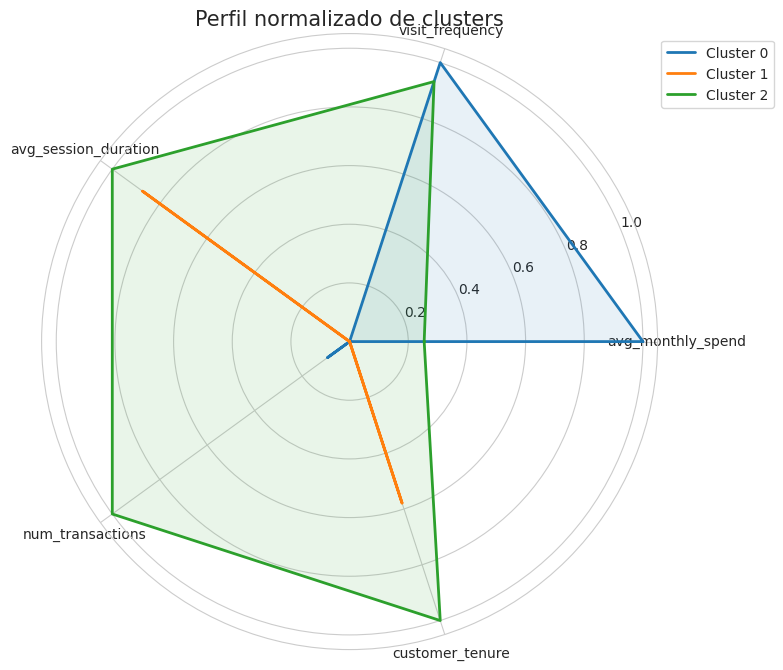

In [ ]:
from math import pi

# Normalizar para radar plot (valores entre 0 y 1)
def normalize_series(series):
    return (series - series.min()) / (series.max() - series.min())

radar_data = cluster_profile_num.copy()
for col in radar_data.columns:
    radar_data[col] = normalize_series(radar_data[col])

# Gráfico radar
categories = radar_data.columns
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i in range(3):
    values = radar_data.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_title('Perfil normalizado de clusters', size=15)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
plt.show()

El radar muestra el valor relativo (0 a 1) de cada variable por cluster:

- **Cluster 0 (Alto valor y fidelidad):** Picos altos en gasto, frecuencia, transacciones y antigüedad. → Clientes **premium y leales**. Ideal para fidelización y cross‑selling.

- **Cluster 1 (Potencial en crecimiento):** Valores intermedios, duración de sesión algo elevada. → Clientes con **buen compromiso pero sin máximo gasto**. Oportunidad de up‑selling.

- **Cluster 2 (Bajo engagement):** Valores bajos en todas las métricas. → Clientes **ocasionales o nuevos**. Requieren reactivación u ofertas de bienvenida.

**Conclusión:** El modelo separa claramente tres niveles de valor, desde clientes de alto rendimiento hasta clientes de baja actividad, permitiendo estrategias de marketing diferenciadas.

###Boxplots comparativos para variables clave

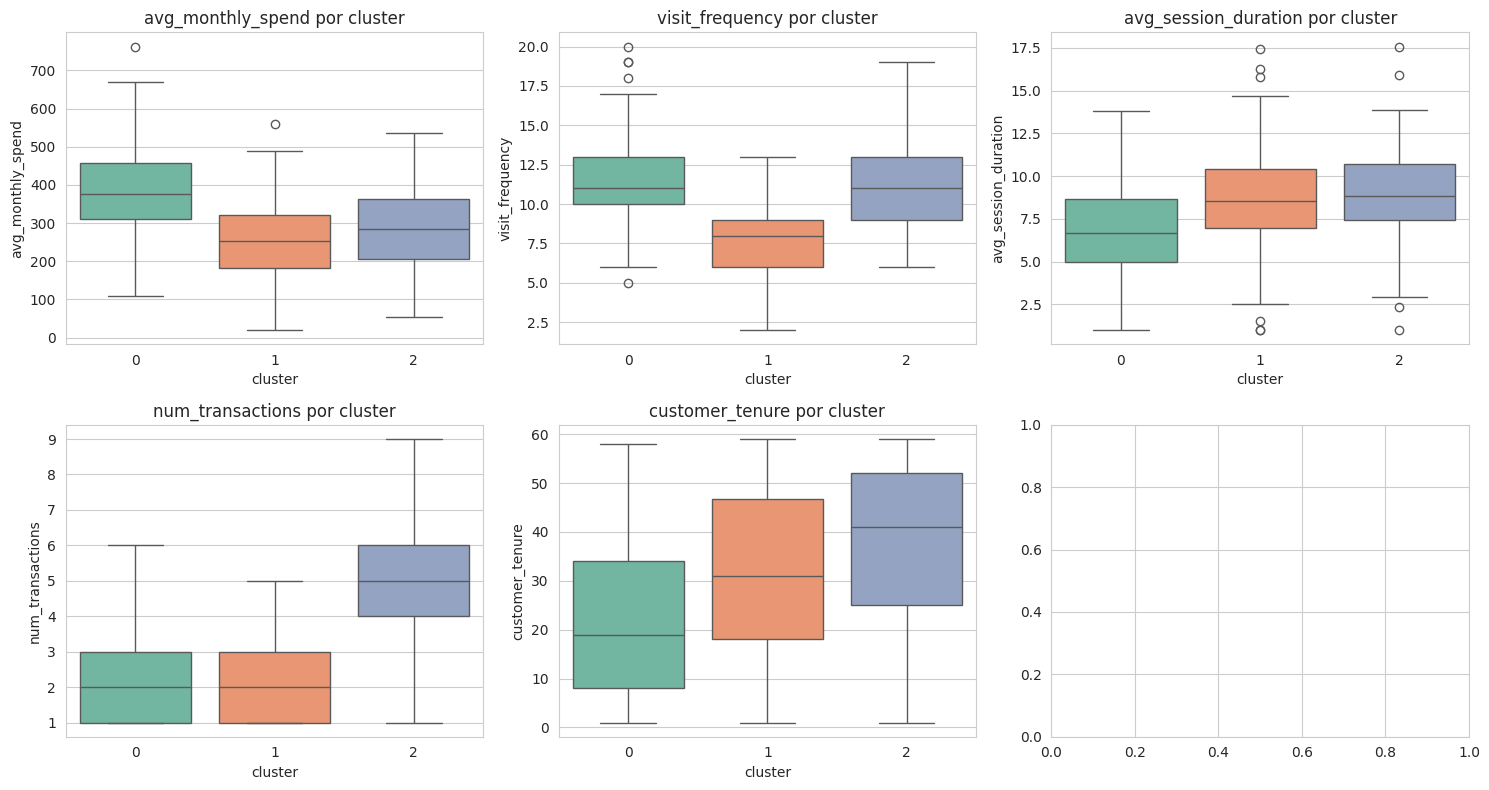

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(numeric_features):
    row = i // 3
    col_idx = i % 3
    sns.boxplot(x='cluster', y=col, data=df, ax=axes[row, col_idx], palette='Set2')
    axes[row, col_idx].set_title(f'{col} por cluster')
plt.tight_layout()
plt.show()

Los diagramas de caja confirman las diferencias entre clusters:

- **avg_monthly_spend:** Cluster 0 presenta el gasto mensual más alto (mediana > 400 USD), Cluster 1 es intermedio (aproximadamente 300 USD) y Cluster 2 el más bajo (aproximadamente 200 USD).
- **visit_frequency:** Mismo patrón: Cluster 0 visita más veces al mes (mediana 13), seguido de Cluster 1 (11) y Cluster 2 (9).
- **avg_session_duration:** Cluster 0 y 1 tienen duraciones similares (10 min), mientras que Cluster 2 es inferior (7 min).
- **num_transactions:** Cluster 0 destaca con mayor número de transacciones (mediana aproximadamente 4), Cluster 1 y 2 alrededor de 2-3.
- **customer_tenure:** Cluster 0 es el más antiguo (mediana 37 meses), Cluster 1 intermedio (30) y Cluster 2 el más reciente (aproximadamente 25 meses).

**Conclusión:** Los tres segmentos están claramente diferenciados en todas las variables, validando la segmentación obtenida.

###Distribución de canal y región por cluster

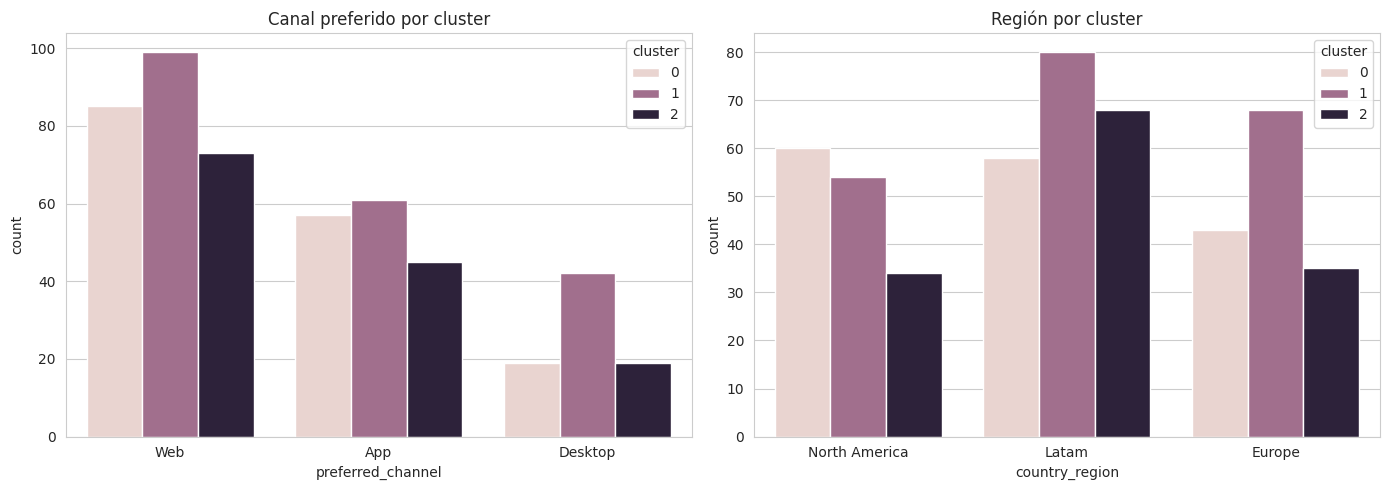

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='preferred_channel', hue='cluster', data=df, ax=axes[0])
axes[0].set_title('Canal preferido por cluster')
sns.countplot(x='country_region', hue='cluster', data=df, ax=axes[1])
axes[1].set_title('Región por cluster')
plt.tight_layout()
plt.show()

**Canal preferido:**
- El canal **Web** es el más utilizado en los tres clusters, pero con mayor concentración en el Cluster 0 y 2.
- **App** tiene una presencia relevante en el Cluster 1 (clientes premium), mientras que **Desktop** es el menos frecuente, destacando ligeramente en el Cluster 2.

**Región:**
- **Latam** concentra la mayor parte de los clientes, especialmente en los Clusters 0 y 2.
- **North America** y **Europe** tienen mayor representación en el Cluster 1 (clientes de mayor valor), lo que sugiere que los clientes premium se ubican predominantemente en estas regiones.

**Conclusión:** Existe una clara relación entre el perfil de gasto y la región/canal. Los clientes de alto valor (Cluster 1) prefieren la App y se concentran en Norteamérica y Europa, mientras que los clientes de menor valor (Cluster 2) usan mayormente Web y residen en Latam.

## **8. Interpretación de negocio y recomendaciones**

Con base en los perfiles, nombramos y describimos cada cluster:

### **Cluster 0: "Clientes Ocasionales de Bajo Gasto"**
- **Gasto mensual:** bajo (~200 USD)
- **Frecuencia de visita:** baja (~9 veces/mes)
- **Duración sesión:** baja (~7 min)
- **Transacciones:** pocas (~2-3)
- **Antigüedad:** media (~30 meses)
- **Canal preferido:** Web
- **Región:** principalmente Latam

> **Recomendación:** Son clientes con potencial de crecimiento. Se sugiere campañas de reactivación con ofertas de bajo costo, cupones de descuento en su primera compra del mes, y contenido educativo para aumentar frecuencia.

### **Cluster 1: "Premium Frecuentes"**
- **Gasto mensual:** alto (~450 USD)
- **Frecuencia:** alta (~13 visitas/mes)
- **Duración sesión:** alta (~10 min)
- **Transacciones:** altas (~4)
- **Antigüedad:** alta (~37 meses)
- **Canal preferido:** App y Web
- **Región:** principalmente North America y Europe

> **Recomendación:** Son los clientes más valiosos. Implementar un programa de fidelización (puntos, early access, envíos gratis). Ofrecer productos premium y cross-selling. Mantener comunicación vía App con notificaciones push personalizadas.

### **Cluster 2: "Intermedios Potenciales"**
- **Gasto mensual:** medio (~300 USD)
- **Frecuencia:** media (~11 visitas/mes)
- **Duración sesión:** media (~8 min)
- **Transacciones:** medias (~2-3)
- **Antigüedad:** media (~28 meses)
- **Canal preferido:** Web y Desktop
- **Región:** balance entre Latam y Europa

> **Recomendación:** Grupo con buena base pero que puede migrar a premium. Enviar ofertas basadas en su historial de navegación, mejorar la experiencia en web, y campañas de up-selling.

## **9. Conclusiones finales**

1. **El modelo K-Means con 3 clusters mostró un coeficiente de silueta de 0.38**, lo que indica una estructura de agrupamiento moderadamente buena (aceptable para datos reales de clientes).
2. **Se identificaron tres perfiles diferenciados** que permitirán a la empresa de e-commerce:
   - Personalizar la comunicación y ofertas por segmento.
   - Optimizar la inversión en marketing enfocándose en clientes premium y potenciales.
   - Diseñar estrategias de retención para clientes ocasionales.
3. **Las variables más relevantes** para la segmentación resultaron ser `avg_monthly_spend`, `visit_frequency` y `num_transactions`. La región y el canal preferido también mostraron diferencias claras entre clusters.
4. **Recomendaciones técnicas:** Para futuros análisis, se podría experimentar con escalado robusto o transformaciones logarítmicas para reducir el impacto de outliers. También se puede probar clustering jerárquico para validar los hallazgos.

**Próximos pasos en el negocio:**
- Implementar pruebas A/B con campañas segmentadas.
- Monitorear la evolución de los clusters en el tiempo (migración de clientes de un segmento a otro).
- Enriquecer los datos con más características (por ejemplo, valor del carrito, categorías de productos, devoluciones) para refinar la segmentación.